In [1]:
import sys
sys.path.append(rf"/Users/baia/Desktop/PYTHON/mba_dsa_usp_esalq")

from TCC.utils.constantes import *

In [2]:
# df_btc_price = pd.read_csv(rf"/home/baia/z/git/data-science-analytics/TCC/data/dados_btc/raw/price_btc.csv")
df_btc_price = pd.read_csv(rf"/Users/baia/Desktop/PYTHON/mba_dsa_usp_esalq/TCC/data/dados_btc/raw/price_btc.csv")
df_btc_price['Data_UTC'] = pd.to_datetime(df_btc_price['time'], unit='s', utc=True,).dt.strftime("%Y-%m-%d")

df_sp500 = (pd.read_csv(rf"/Users/baia/Desktop/PYTHON/mba_dsa_usp_esalq/TCC/data/dados_macro/raw/2014_SP500_PRICE.csv")

                         .assign(Data_UTC = lambda df: pd.to_datetime(df['time'], utc=True))
                         .assign(Data_UTC = lambda df: df['Data_UTC'].dt.strftime("%Y-%m-%d"))

                        .rename(columns={'close': 'close_price'}) 

                        [['Data_UTC', 'close_price']] 
 
)

df_sp500_log_Ret =(
    df_periodo
        .merge(df_sp500, how='left', on='Data_UTC')
        # Preço se mantém ao FDS
        .assign(close_price = lambda df: df['close_price'].fillna(method='ffill'))
        .assign(SPX_Log_Ret = lambda df: np.log(df['close_price']) - np.log(df['close_price'].shift(1)))


        .query("Data_UTC > '2017-01-03'")
        [['Data_UTC','close_price','SPX_Log_Ret']]

)
df_sp500_log_Ret

df_vix = (pd.read_csv(rf"/Users/baia/Desktop/PYTHON/mba_dsa_usp_esalq/TCC/data/dados_macro/raw/201501_VIX.csv")

                        .assign(Data_UTC = lambda df: pd.to_datetime(df['time'],unit='s', utc=True))
                        .assign(Data_UTC = lambda df: df['Data_UTC'].dt.strftime("%Y-%m-%d"))
                        .rename(columns={'close': 'close_price'}) 

                        [['Data_UTC', 'close_price']] 
 
)
df_vix

df_vix_log_ret =(
    df_periodo
        .merge(df_vix, how='left', on='Data_UTC')
        .assign(close_price = lambda df: df['close_price'].ffill())
        .assign(VIX_Log_Ret = lambda df: np.log(df['close_price']) - np.log(df['close_price'].shift(1)))

        .query("Data_UTC > '2017-01-03'")
        [['Data_UTC','close_price','VIX_Log_Ret']]

)
df_vix_log_ret

df_us10y = (pd.read_csv(rf"/Users/baia/Desktop/PYTHON/mba_dsa_usp_esalq/TCC/data/dados_macro/raw/201501_US10Y.csv")

                        .assign(Data_UTC = lambda df: pd.to_datetime(df['time'],unit='s', utc=True))
                        .assign(Data_UTC = lambda df: df['Data_UTC'].dt.strftime("%Y-%m-%d"))
                        .rename(columns={'close': 'close_price'}) 

                        [['Data_UTC', 'close_price']] 
 
)
df_us10y

df_us10y_diff =(
    df_periodo
        .merge(df_us10y, how='left', on='Data_UTC')
        .assign(close_price = lambda df: df['close_price'].ffill())
        .assign(US10Y_Diff = lambda df: df['close_price'].diff())

        .query("Data_UTC > '2017-01-03'")
        [['Data_UTC','close_price','US10Y_Diff']]

)
df_us10y_diff

/var/folders/h1/_3z4z04x4j17zlfj224w53hr0000gn/T/ipykernel_4347/4063713309.py:20: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  .assign(close_price = lambda df: df['close_price'].fillna(method='ffill'))


,Data_UTC,close_price,US10Y_Diff
4,2017-01-04,2.4413,-0.0059
5,2017-01-05,2.3479,-0.0934
6,2017-01-06,2.4221,0.0742
7,2017-01-07,2.4221,0.0000
8,2017-01-08,2.4221,0.0000
...,...,...,...
3131,2025-07-28,4.3240,-0.0900
3132,2025-07-29,4.3720,0.0480
3133,2025-07-30,4.3820,0.0100
3134,2025-07-31,4.2160,-0.1660


In [3]:
# Base dataframe
df_final_feature = df_periodo.copy()

# Left join com df_btc_price
df_final_feature = df_final_feature.merge(
    df_btc_price[['Data_UTC', 'close']],
    on='Data_UTC',
    how='left'
).rename(columns={
    'close': 'btc_close'
})

# Left join com df_sp500_log_Ret
df_final_feature = df_final_feature.merge(
    df_sp500_log_Ret,
    on='Data_UTC',
    how='left'
).rename(columns={'close_price': 'sp500_close'})

# Left join com df_vix_log_ret
df_final_feature = df_final_feature.merge(
    df_vix_log_ret,
    on='Data_UTC',
    how='left'
).rename(columns={'close_price': 'vix_close'})

# Left join com df_us10y_diff
df_final_feature = df_final_feature.merge(
    df_us10y_diff,
    on='Data_UTC',
    how='left'
).rename(columns={'close_price': 'us10y_close'})

df_final_feature = df_final_feature.ffill().query("Data_UTC >= '2017-01-04'").reset_index(drop=True)

df_final_feature = df_final_feature.assign(Data_UTC=pd.to_datetime(df_final_feature['Data_UTC']))

df_final_feature = df_final_feature.assign( btc_Log_Ret = lambda df: np.log(df['btc_close']) - np.log(df['btc_close'].shift(1)))
df_final_feature

,Data_UTC,btc_close,sp500_close,SPX_Log_Ret,vix_close,VIX_Log_Ret,us10y_close,US10Y_Diff,btc_Log_Ret
0,2017-01-04,1130.39975,2270.75,0.005706,11.85,-0.081016,2.4413,-0.0059,NaN
1,2017-01-05,1005.64250,2269.00,-0.000771,11.67,-0.015306,2.3479,-0.0934,-0.116945
2,2017-01-06,894.70325,2276.98,0.003511,11.32,-0.030450,2.4221,0.0742,-0.116890
3,2017-01-07,907.65000,2276.98,0.000000,11.32,0.000000,2.4221,0.0000,0.014367
4,2017-01-08,915.99975,2276.98,0.000000,11.32,0.000000,2.4221,0.0000,0.009157
...,...,...,...,...,...,...,...,...,...
3127,2025-07-28,118085.05000,6389.76,0.000174,15.04,0.008011,4.3240,-0.0900,-0.011507
3128,2025-07-29,117940.69000,6370.87,-0.002961,15.97,0.059999,4.3720,0.0480,-0.001223
3129,2025-07-30,117815.05000,6362.89,-0.001253,15.47,-0.031809,4.3820,0.0100,-0.001066
3130,2025-07-31,115760.52000,6339.38,-0.003702,16.71,0.077105,4.2160,-0.1660,-0.017592


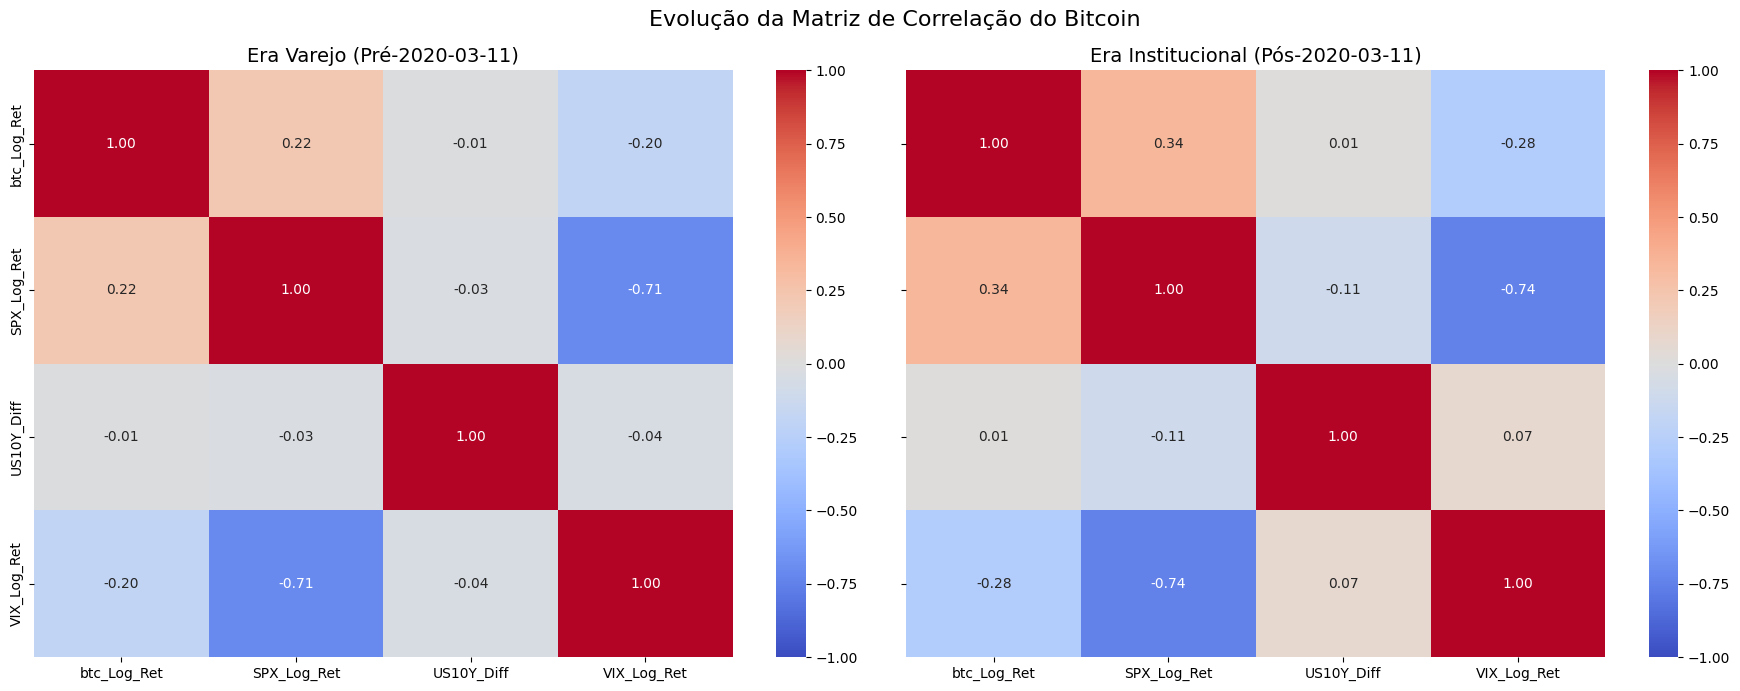

In [ ]:
# ==============================================================================
# 3. MATRIZES DE CORRELAÇÃO COMPARATIVAS (Para a Seção 3.3)
# ==============================================================================

# Selecionar variáveis TRANSFORMADAS (Stationary)
cols_corr = ['btc_Log_Ret', 'SPX_Log_Ret','US10Y_Diff', 'VIX_Log_Ret']

# Dividir os dados
df_varejo = df_final_feature.loc[:DATA_DIVISAO_ERA][cols_corr]
df_institucional = df_final_feature.loc[DATA_DIVISAO_ERA:][cols_corr]
# Calcular Matrizes de Correlação (Pearson)
corr_varejo = df_varejo.corr()
corr_institucional = df_institucional.corr()

# Plotar Lado a Lado
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

# Heatmap 1: Era Varejo
sns.heatmap(corr_varejo, ax=axes[0], annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
axes[0].set_title(f'Era Varejo (Pré-{DATA_DIVISAO_ERA})', fontsize=14)

# Heatmap 2: Era Institucional
sns.heatmap(corr_institucional, ax=axes[1], annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
axes[1].set_title(f'Era Institucional (Pós-{DATA_DIVISAO_ERA})', fontsize=14)
plt.suptitle('Evolução da Matriz de Correlação do Bitcoin', fontsize=16)
plt.tight_layout()
plt.show()

# O que procurar aqui: Veja se o quadrado entre btc_Log_Ret e SPX_Log_Ret ficou "mais vermelho" no segundo gráfico. 
# Se sim, sua tese está provada visualmente.